<a href="https://colab.research.google.com/github/AdilM01/AI-Projects/blob/feature%2Fai-projects/End-to-End%20NLP%20Pipeline%20for%20Twitter%20Sentiment%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import nltk

resources = [
    "punkt",
    "punkt_tab",
    "stopwords",
    "wordnet",
    "omw-1.4",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng"
]

for resource in resources:
    nltk.download(resource)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [ ]:
!pip install -q \
datasets \
nltk \
gensim \
sentence-transformers \
pyspellchecker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 112.6 MB/s eta 0:00:00


In [ ]:
!pip install autocorrect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 622.8/622.8 kB 44.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for autocorrect: filename=autocorrect-2.6.1-py3-none-any.whl size=622364 sha256=516a1b8454ccb90fd5a69f7b9d74ad4435b1c54e339cc90a59112dda02dad242
  Stored in directory: /root/.cache/pip/wheels/b6/28/c2/9ddf8f57f871b55b6fd0ab99c887531fb9a66e5ff236b82aee
Successfully built autocorrect


In [ ]:
import os, re, json, time, random, string, warnings
from functools import lru_cache
from collections import Counter
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import emoji
import contractions
from bs4 import BeautifulSoup
from autocorrect import Speller

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, LancasterStemmer, SnowballStemmer, WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

import gensim
import gensim.downloader as gensim_api
from gensim.models import Word2Vec
from sentence_transformers import SentenceTransformer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, SimpleRNN, LSTM, Reshape
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)
print("Gensim version:", gensim.__version__)

TensorFlow version: 2.20.0
Gensim version: 4.4.0


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

In [ ]:
DATA_PATH = "/content/Tweets.csv"

raw_df = pd.read_csv(DATA_PATH)
df = raw_df[["text", "airline_sentiment"]].copy()
df.rename(columns={"text": "original_text", "airline_sentiment": "label_name"}, inplace=True)
df = df.dropna(subset=["original_text", "label_name"]).reset_index(drop=True)

LABEL_NAMES = sorted(df["label_name"].unique().tolist())
label_to_int = {name: i for i, name in enumerate(LABEL_NAMES)}
df["label"] = df["label_name"].map(label_to_int)

print("Shape:", df.shape)
display(df.head())
print(df.isnull().sum())
df.info()

Shape: (14640, 3)


,original_text,label_name,label
0,@VirginAmerica What @dhepburn said.,neutral,1
1,@VirginAmerica plus you've added commercials t...,positive,2
2,@VirginAmerica I didn't today... Must mean I n...,neutral,1
3,@VirginAmerica it's really aggressive to blast...,negative,0
4,@VirginAmerica and it's a really big bad thing...,negative,0


original_text    0
label_name       0
label            0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   original_text  14640 non-null  object
 1   label_name     14640 non-null  object
 2   label          14640 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 343.3+ KB


In [ ]:
NUM_CLASSES = len(LABEL_NAMES)
print("Dataset source : Kaggle / Crowdflower 'Twitter US Airline Sentiment' (Tweets.csv)")
print("Number of samples :", len(df))
print("Number of classes :", NUM_CLASSES)
print("Label names :", LABEL_NAMES)

Dataset source : Kaggle / Crowdflower 'Twitter US Airline Sentiment' (Tweets.csv)
Number of samples : 14640
Number of classes : 3
Label names : ['negative', 'neutral', 'positive']


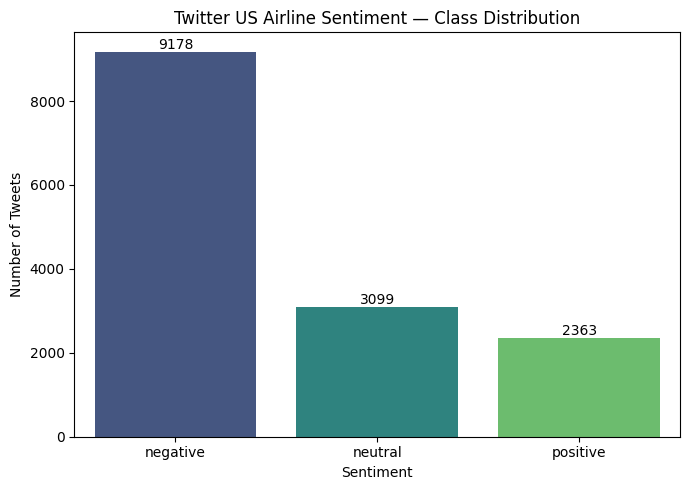

label_name
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(7, 5))
order = df["label_name"].value_counts().index
ax = sns.countplot(data=df, x="label_name", order=order, palette="viridis")
plt.title("Twitter US Airline Sentiment — Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom")
plt.tight_layout()
plt.show()
print(df["label_name"].value_counts())

In [ ]:
STOPWORDS = set(stopwords.words("english"))
spell = Speller(lang="en")

def step_lowercase(text): return text.lower()
def step_expand_contractions(text): return contractions.fix(text)
def step_remove_html(text): return BeautifulSoup(text, "html.parser").get_text()

URL_RE = re.compile(r"https?://\S+|www\.\S+")
def step_remove_urls(text): return URL_RE.sub(" ", text)

EMAIL_RE = re.compile(r"\S+@\S+")
def step_remove_emails(text): return EMAIL_RE.sub(" ", text)

MENTION_RE = re.compile(r"@\w+")
def step_remove_mentions(text): return MENTION_RE.sub(" ", text)

def step_remove_hashtag_symbol(text): return text.replace("#", "")
def step_remove_emojis(text): return emoji.replace_emoji(text, replace=" ")

PUNCT_TABLE = str.maketrans("", "", string.punctuation)
def step_remove_punctuation(text): return text.translate(PUNCT_TABLE)

DIGIT_RE = re.compile(r"\d+")
def step_remove_digits(text): return DIGIT_RE.sub(" ", text)

def step_remove_extra_spaces(text): return re.sub(r"\s+", " ", text).strip()
def step_remove_stopwords(tokens): return [t for t in tokens if t not in STOPWORDS]
def step_remove_short_words(tokens): return [t for t in tokens if len(t) > 2 or t in ("i", "a")]

@lru_cache(maxsize=200_000)
def _correct_word(word):
    try:
        return spell(word)
    except Exception:
        return word

def step_spelling_correction(tokens): return [_correct_word(t) for t in tokens]
def step_rejoin(tokens): return " ".join(tokens)

def clean_text_pipeline(text, apply_spelling_correction=True):
    text = step_lowercase(text)
    text = step_expand_contractions(text)
    text = step_remove_html(text)
    text = step_remove_urls(text)
    text = step_remove_emails(text)
    text = step_remove_mentions(text)
    text = step_remove_hashtag_symbol(text)
    text = step_remove_emojis(text)
    text = step_remove_punctuation(text)
    text = step_remove_digits(text)
    text = step_remove_extra_spaces(text)
    tokens = text.split()
    tokens = step_remove_stopwords(tokens)
    tokens = step_remove_short_words(tokens)
    if apply_spelling_correction:
        tokens = step_spelling_correction(tokens)
    tokens = word_tokenize(" ".join(tokens))
    return step_rejoin(tokens)

In [ ]:
QUICK_MODE = True

if QUICK_MODE:
    SAMPLE_SIZE = 3000
    MAX_FEATURES = 2000
    EPOCHS = 6
    APPLY_SPELLING_CORRECTION = True
else:
    SAMPLE_SIZE = None
    MAX_FEATURES = 5000
    EPOCHS = 25
    APPLY_SPELLING_CORRECTION = True

if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df):
    df, _ = train_test_split(df, train_size=SAMPLE_SIZE, stratify=df["label"], random_state=SEED)
    df = df.reset_index(drop=True)

print(f"QUICK_MODE={QUICK_MODE} | Working dataset size: {len(df)}")

QUICK_MODE=True | Working dataset size: 3000


In [ ]:
t0 = time.time()
df["clean_text"] = df["original_text"].apply(lambda t: clean_text_pipeline(t, apply_spelling_correction=APPLY_SPELLING_CORRECTION))
print(f"Cleaned {len(df)} tweets in {time.time() - t0:.1f}s")

for i in range(5):
    print("-" * 80)
    print("BEFORE:", df['original_text'].iloc[i])
    print("AFTER :", df['clean_text'].iloc[i])

Cleaned 3000 tweets in 102.6s
--------------------------------------------------------------------------------
BEFORE: @united - I think she was having a rough moment w/ a bad passenger from an earlier flight. Things got considerably better. Thanks!
AFTER : think rough moment bad passenger earlier flight things got considerably better thanks
--------------------------------------------------------------------------------
BEFORE: @AmericanAir I dmed
AFTER : died
--------------------------------------------------------------------------------
BEFORE: @USAirways instead of tweeting your customers apologizing why don't you pick up your phone
AFTER : instead meeting customers apologizing pick phone
--------------------------------------------------------------------------------
BEFORE: Thank you United! “@united: @dan_roam That's a beautiful place to stay a day longer. Have you been re-booked? If not, let me know. ^MN”
AFTER : thank united beautiful place stay day longer revoked let know mn

In [ ]:
porter = PorterStemmer()
lancaster = LancasterStemmer()
snowball = SnowballStemmer("english")

REGEX_STEMMER_RULES = [
    (r"(ational)$", "ate"), (r"(tional)$", "tion"), (r"(izer|ization|ising|isation)$", "ize"),
    (r"(ies|ied)$", "y"), (r"(ing)$", ""), (r"(edly)$", ""), (r"(ed)$", ""),
    (r"(ness)$", ""), (r"(ful)$", ""), (r"(ment)$", ""), (r"(able|ible)$", ""),
    (r"(ly)$", ""), (r"(s)$", ""),
]
COMPILED_REGEX_RULES = [(re.compile(p), r) for p, r in REGEX_STEMMER_RULES]

def regex_stem(word):
    if len(word) <= 3:
        return word
    for pattern, repl in COMPILED_REGEX_RULES:
        new_word, n = pattern.subn(repl, word)
        if n:
            return new_word if len(new_word) > 2 else word
    return word

def stem_sentence(sentence, stemmer_fn):
    return " ".join(stemmer_fn(tok) for tok in sentence.split())

df["stem_porter"]    = df["clean_text"].apply(lambda s: stem_sentence(s, porter.stem))
df["stem_lancaster"] = df["clean_text"].apply(lambda s: stem_sentence(s, lancaster.stem))
df["stem_snowball"]  = df["clean_text"].apply(lambda s: stem_sentence(s, snowball.stem))
df["stem_regexp"]    = df["clean_text"].apply(lambda s: stem_sentence(s, regex_stem))

df[["clean_text", "stem_porter", "stem_lancaster", "stem_snowball", "stem_regexp"]].head()

,clean_text,stem_porter,stem_lancaster,stem_snowball,stem_regexp
0,think rough moment bad passenger earlier fligh...,think rough moment bad passeng earlier flight ...,think rough mom bad passeng ear flight thing g...,think rough moment bad passeng earlier flight ...,think rough moment bad passenger earlier fligh...
1,died,die,died,die,died
2,instead meeting customers apologizing pick phone,instead meet custom apolog pick phone,instead meet custom apolog pick phon,instead meet custom apolog pick phone,instead meet customer apologiz pick phone
3,thank united beautiful place stay day longer r...,thank unit beauti place stay day longer revok ...,thank unit beauty plac stay day long revok let...,thank unit beauti place stay day longer revok ...,thank unit beauti place stay day longer revok ...
4,bag fee golf bag domestic flight,bag fee golf bag domest flight,bag fee golf bag domest flight,bag fee golf bag domest flight,bag fee golf bag domestic flight


In [ ]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith("J"): return wordnet.ADJ
    elif tag.startswith("V"): return wordnet.VERB
    elif tag.startswith("N"): return wordnet.NOUN
    elif tag.startswith("R"): return wordnet.ADV
    else: return wordnet.NOUN

def lemmatize_sentence(sentence):
    tokens = sentence.split()
    if not tokens:
        return ""
    tagged = pos_tag(tokens)
    return " ".join(lemmatizer.lemmatize(tok, get_wordnet_pos(tag)) for tok, tag in tagged)

df["lemma"] = df["clean_text"].apply(lemmatize_sentence)
df[["clean_text", "lemma"]].head()

,clean_text,lemma
0,think rough moment bad passenger earlier fligh...,think rough moment bad passenger earlier fligh...
1,died,die
2,instead meeting customers apologizing pick phone,instead meeting customer apologize pick phone
3,thank united beautiful place stay day longer r...,thank united beautiful place stay day longer r...
4,bag fee golf bag domestic flight,bag fee golf bag domestic flight


In [ ]:
final_columns = ["original_text", "clean_text", "stem_porter", "stem_lancaster",
                  "stem_snowball", "stem_regexp", "lemma", "label", "label_name"]
final_df = df[final_columns].reset_index(drop=True)
print("Final dataframe shape:", final_df.shape)
final_df.head(10)

Final dataframe shape: (3000, 9)


,original_text,clean_text,stem_porter,stem_lancaster,stem_snowball,stem_regexp,lemma,label,label_name
0,@united - I think she was having a rough momen...,think rough moment bad passenger earlier fligh...,think rough moment bad passeng earlier flight ...,think rough mom bad passeng ear flight thing g...,think rough moment bad passeng earlier flight ...,think rough moment bad passenger earlier fligh...,think rough moment bad passenger earlier fligh...,2,positive
1,@AmericanAir I dmed,died,die,died,die,died,die,0,negative
2,@USAirways instead of tweeting your customers ...,instead meeting customers apologizing pick phone,instead meet custom apolog pick phone,instead meet custom apolog pick phon,instead meet custom apolog pick phone,instead meet customer apologiz pick phone,instead meeting customer apologize pick phone,0,negative
3,Thank you United! “@united: @dan_roam That's a...,thank united beautiful place stay day longer r...,thank unit beauti place stay day longer revok ...,thank unit beauty plac stay day long revok let...,thank unit beauti place stay day longer revok ...,thank unit beauti place stay day longer revok ...,thank united beautiful place stay day longer r...,2,positive
4,@USAirways so it's a $25.00 bag fee for a golf...,bag fee golf bag domestic flight,bag fee golf bag domest flight,bag fee golf bag domest flight,bag fee golf bag domest flight,bag fee golf bag domestic flight,bag fee golf bag domestic flight,1,neutral
5,@united just tried to log in and was told e-ma...,tried log told email log currently available,tri log told email log current avail,tri log told email log cur avail,tri log told email log current avail,try log told email log current avail,try log tell email log currently available,0,negative
6,@SouthwestAir 8 mins!!! http://t.co/bbZiJWFDL3,mins,min,min,min,min,min,1,neutral
7,@JetBlue any chance you will by this summer?,chance summer,chanc summer,chant sum,chanc summer,chance summer,chance summer,1,neutral
8,"@AmericanAir no worries, loved flying with you...",worries loved flying guys thanks,worri love fli guy thank,worry lov fly guy thank,worri love fli guy thank,worry lov fly guy thank,worry love fly guy thanks,2,positive
9,“@united: @BattierCCIpuppy We hope to see you ...,hope see board soon thanks tweet ey ”,hope see board soon thank tweet ey ”,hop see board soon thank tweet ey ”,hope see board soon thank tweet ey ”,hope see board soon thank tweet ey ”,hope see board soon thanks tweet ey ”,2,positive


In [ ]:
TEXT_VARIANTS = ["stem_porter", "stem_lancaster", "stem_snowball", "stem_regexp", "lemma"]
y_int = final_df["label"].values
y_cat = to_categorical(y_int, num_classes=NUM_CLASSES)

In [ ]:
def rep_onehot(corpus):
    vec = CountVectorizer(binary=True, max_features=MAX_FEATURES)
    X = vec.fit_transform(corpus)
    return X, vec

def rep_bow(corpus):
    vec = CountVectorizer(max_features=MAX_FEATURES)
    X = vec.fit_transform(corpus)
    return X, vec

def rep_ngrams(corpus):
    vec = CountVectorizer(ngram_range=(1, 2), max_features=MAX_FEATURES)
    X = vec.fit_transform(corpus)
    return X, vec

def rep_tfidf(corpus):
    vec = TfidfVectorizer(max_features=MAX_FEATURES, min_df=2, max_df=0.9)
    X = vec.fit_transform(corpus)
    return X, vec

W2V_PARAMS = dict(vector_size=100, window=5, min_count=2, epochs=20, seed=SEED, workers=1)

def mean_pool(tokens, keyed_vectors, dim):
    vectors = [keyed_vectors[t] for t in tokens if t in keyed_vectors]
    if not vectors:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

def rep_word2vec(corpus):
    tokenized = [s.split() for s in corpus]
    model = Word2Vec(sentences=tokenized, **W2V_PARAMS)
    X = np.array([mean_pool(toks, model.wv, W2V_PARAMS["vector_size"]) for toks in tokenized])
    return X, model

_glove_cache = {"model": None}
def load_glove():
    if _glove_cache["model"] is None:
        _glove_cache["model"] = gensim_api.load("glove-wiki-gigaword-100")
    return _glove_cache["model"]

def rep_glove(corpus):
    glove = load_glove()
    tokenized = [s.split() for s in corpus]
    X = np.array([mean_pool(toks, glove, 100) for toks in tokenized])
    return X, glove

_bert_cache = {"model": None}
def load_bert():
    if _bert_cache["model"] is None:
        _bert_cache["model"] = SentenceTransformer("all-MiniLM-L6-v2")
    return _bert_cache["model"]

def rep_bert(corpus):
    bert = load_bert()
    X = bert.encode(list(corpus), show_progress_bar=False, batch_size=64)
    return np.array(X), bert

# ELMo skipped: TF1-only, unmaintained; superseded here by GloVe + BERT
REPRESENTATIONS = {
    "OneHot": rep_onehot, "BoW": rep_bow, "NGrams(1,2)": rep_ngrams, "TFIDF": rep_tfidf,
    "Word2Vec": rep_word2vec, "GloVe": rep_glove, "BERT": rep_bert,
}
print("Representations registered:", list(REPRESENTATIONS.keys()), "+ ELMo (skipped)")

Representations registered: ['OneHot', 'BoW', 'NGrams(1,2)', 'TFIDF', 'Word2Vec', 'GloVe', 'BERT'] + ELMo (skipped)


In [ ]:
TEST_SIZE = 0.2

def split_data(X, y_int, y_cat):
    X_train, X_test, y_train_int, y_test_int, y_train_cat, y_test_cat = train_test_split(
        X, y_int, y_cat, test_size=TEST_SIZE, stratify=y_int, random_state=SEED)
    return X_train, X_test, y_train_int, y_test_int, y_train_cat, y_test_cat

In [ ]:
def build_ann(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)), Dense(256, activation="relu"), Dropout(0.3),
        Dense(128, activation="relu"), Dropout(0.3), Dense(num_classes, activation="softmax"),
    ], name="ANN")
    model.compile(optimizer=Adam(learning_rate=1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

def build_rnn(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)), Reshape((1, input_dim)), SimpleRNN(128, activation="tanh"),
        Dropout(0.3), Dense(64, activation="relu"), Dense(num_classes, activation="softmax"),
    ], name="RNN")
    model.compile(optimizer=Adam(learning_rate=1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

def build_lstm(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)), Reshape((1, input_dim)), LSTM(128, activation="tanh"),
        Dropout(0.3), Dense(64, activation="relu"), Dense(num_classes, activation="softmax"),
    ], name="LSTM")
    model.compile(optimizer=Adam(learning_rate=1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

MODEL_BUILDERS = {"ANN": build_ann, "RNN": build_rnn, "LSTM": build_lstm}
EARLY_STOPPING = lambda: EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
print(build_ann(100, NUM_CLASSES).summary())

Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,139 (231.01 KB)

 Trainable params: 59,139 (231.01 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
results = []
histories = {}
predictions_store = {}
REP_NAMES = list(REPRESENTATIONS.keys())
experiment_id = 0
total_experiments = len(TEXT_VARIANTS) * len(REP_NAMES) * len(MODEL_BUILDERS)
t_start = time.time()

FEATURE_STORE = {}
print("Building features...")
for variant in TEXT_VARIANTS:
    for rep_name, rep_fn in REPRESENTATIONS.items():
        text_data = final_df[variant].tolist()
        X, _ = rep_fn(text_data)

        # Fix for SparseToDense error: reorder sparse matrices
        if hasattr(X, "tocoo"):
            X_coo = X.tocoo()
            # Updated to be compatible with NumPy 2.0 (avoiding np.mat)
            indices = np.column_stack((X_coo.row, X_coo.col))
            X_sparse = tf.sparse.SparseTensor(indices, X_coo.data, X_coo.shape)
            X_reordered = tf.sparse.reorder(X_sparse)
            # Convert to dense for models using Input(shape=(input_dim,))
            X = tf.sparse.to_dense(X_reordered).numpy()

        FEATURE_STORE[(variant, rep_name)] = X
print("Features built successfully.")

for variant in TEXT_VARIANTS:
    for rep_name in REP_NAMES:
        X = FEATURE_STORE[(variant, rep_name)]
        X_train, X_test, y_train_int, y_test_int, y_train_cat, y_test_cat = split_data(X, y_int, y_cat)
        input_dim = X_train.shape[1]

        for model_name, builder in MODEL_BUILDERS.items():
            experiment_id += 1
            tf.keras.backend.clear_session()
            model = builder(input_dim, NUM_CLASSES)
            history = model.fit(X_train, y_train_cat, validation_split=0.1, epochs=EPOCHS,
                                 batch_size=32, callbacks=[EARLY_STOPPING()], verbose=0)

            y_pred_prob = model.predict(X_test, verbose=0)
            y_pred_int = np.argmax(y_pred_prob, axis=1)

            acc = accuracy_score(y_test_int, y_pred_int)
            prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_test_int, y_pred_int, average="macro", zero_division=0)
            _, _, f1_weighted, _ = precision_recall_fscore_support(y_test_int, y_pred_int, average="weighted", zero_division=0)

            results.append({
                "text_variant": variant, "representation": rep_name, "model": model_name,
                "accuracy": acc, "precision_macro": prec_macro, "recall_macro": rec_macro,
                "f1_macro": f1_macro, "f1_weighted": f1_weighted,
            })
            histories[(variant, rep_name, model_name)] = history
            predictions_store[(variant, rep_name, model_name)] = (y_test_int, y_pred_int)

            elapsed = time.time() - t_start
            print(f"[{experiment_id:3d}/{total_experiments}] {variant:14s} | {rep_name:12s} | {model_name:4s} -> acc={acc:.3f} f1_macro={f1_macro:.3f} ({elapsed:.0f}s)")

results_df = pd.DataFrame(results)
results_df.head()

Building features...
Features built successfully.
[  1/105] stem_porter    | OneHot       | ANN  -> acc=0.753 f1_macro=0.648 (17s)
[  2/105] stem_porter    | OneHot       | RNN  -> acc=0.743 f1_macro=0.645 (25s)
[  3/105] stem_porter    | OneHot       | LSTM -> acc=0.738 f1_macro=0.598 (31s)
[  4/105] stem_porter    | BoW          | ANN  -> acc=0.738 f1_macro=0.651 (38s)
[  5/105] stem_porter    | BoW          | RNN  -> acc=0.752 f1_macro=0.661 (46s)
[  6/105] stem_porter    | BoW          | LSTM -> acc=0.727 f1_macro=0.561 (51s)
[  7/105] stem_porter    | NGrams(1,2)  | ANN  -> acc=0.750 f1_macro=0.658 (59s)
[  8/105] stem_porter    | NGrams(1,2)  | RNN  -> acc=0.747 f1_macro=0.655 (67s)
[  9/105] stem_porter    | NGrams(1,2)  | LSTM -> acc=0.748 f1_macro=0.622 (73s)
[ 10/105] stem_porter    | TFIDF        | ANN  -> acc=0.728 f1_macro=0.583 (83s)
[ 11/105] stem_porter    | TFIDF        | RNN  -> acc=0.740 f1_macro=0.618 (90s)
[ 12/105] stem_porter    | TFIDF        | LSTM -> acc=0.738

,text_variant,representation,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,stem_porter,OneHot,ANN,0.753333,0.701494,0.630879,0.648246,0.729979
1,stem_porter,OneHot,RNN,0.743333,0.682937,0.630889,0.644779,0.726159
2,stem_porter,OneHot,LSTM,0.738333,0.700321,0.594278,0.597612,0.697454
3,stem_porter,BoW,ANN,0.738333,0.671954,0.642832,0.651087,0.726446
4,stem_porter,BoW,RNN,0.751667,0.694727,0.649924,0.661474,0.737458


In [ ]:
for (variant, rep_name, model_name), (y_true, y_pred) in predictions_store.items():
    print("=" * 90)
    print(f"Text Variant: {variant} | Representation: {rep_name} | Model: {model_name}")
    print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, zero_division=0))

Text Variant: stem_porter | Representation: OneHot | Model: ANN
              precision    recall  f1-score   support

    negative       0.78      0.93      0.85       376
     neutral       0.61      0.31      0.41       127
    positive       0.72      0.65      0.68        97

    accuracy                           0.75       600
   macro avg       0.70      0.63      0.65       600
weighted avg       0.73      0.75      0.73       600

Text Variant: stem_porter | Representation: OneHot | Model: RNN
              precision    recall  f1-score   support

    negative       0.79      0.90      0.84       376
     neutral       0.61      0.36      0.46       127
    positive       0.65      0.63      0.64        97

    accuracy                           0.74       600
   macro avg       0.68      0.63      0.64       600
weighted avg       0.73      0.74      0.73       600

Text Variant: stem_porter | Representation: OneHot | Model: LSTM
              precision    recall  f1-score  

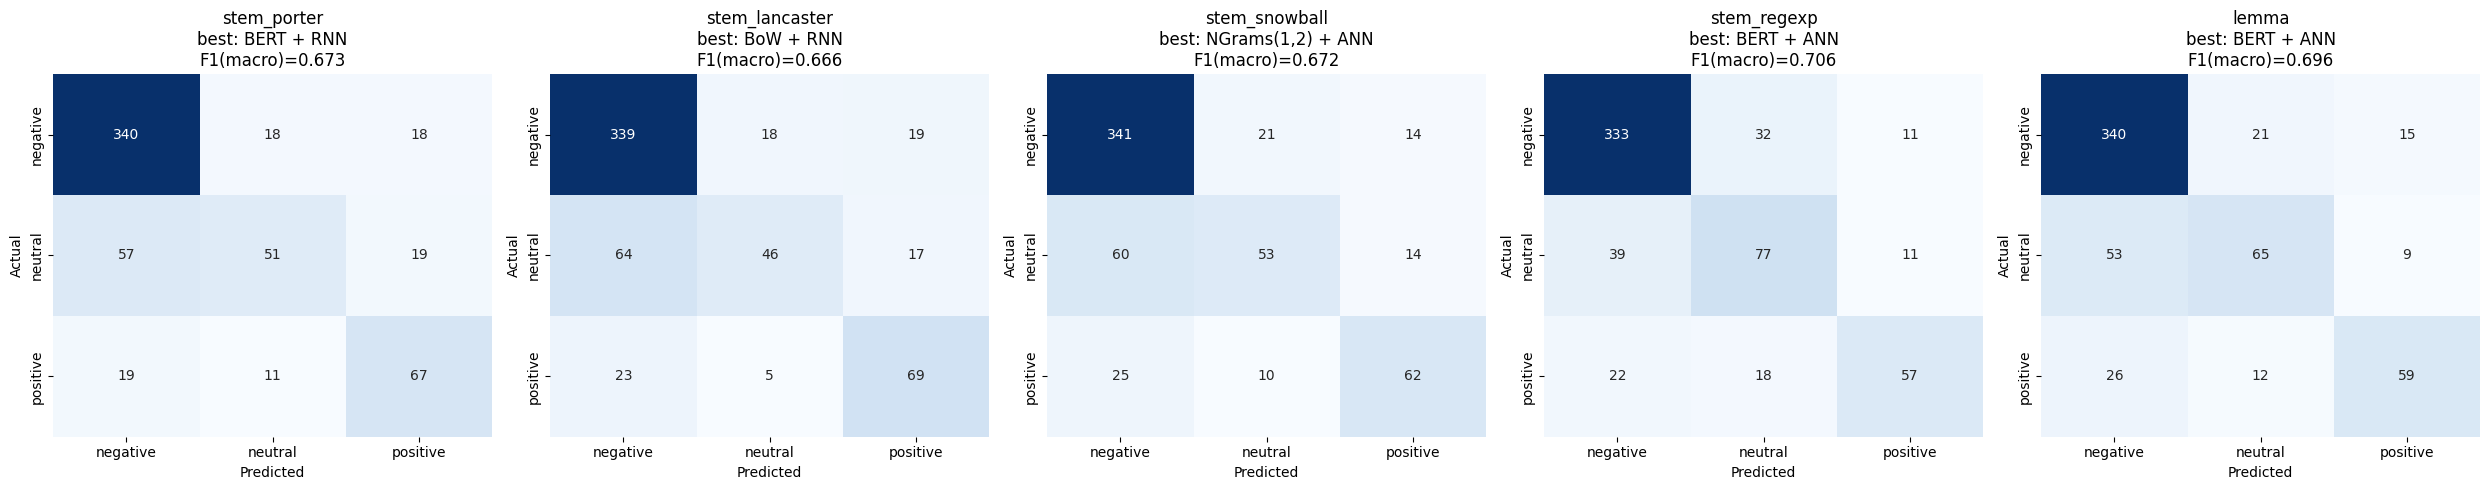

In [ ]:
fig, axes = plt.subplots(1, len(TEXT_VARIANTS), figsize=(5 * len(TEXT_VARIANTS), 5))
for ax, variant in zip(axes, TEXT_VARIANTS):
    sub = results_df[results_df["text_variant"] == variant]
    best_row = sub.loc[sub["f1_macro"].idxmax()]
    key = (variant, best_row["representation"], best_row["model"])
    y_true, y_pred = predictions_store[key]
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
    ax.set_title(f"{variant}\nbest: {best_row['representation']} + {best_row['model']}\nF1(macro)={best_row['f1_macro']:.3f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
def build_comparison_table(model_name):
    sub = results_df[results_df["model"] == model_name].copy()
    sub["variant_x_representation"] = sub["text_variant"] + " | " + sub["representation"]
    table = sub.set_index("variant_x_representation")[["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_weighted"]].round(4)
    elmo_rows = pd.DataFrame({c: ["NA - skipped"] * len(TEXT_VARIANTS) for c in table.columns},
                              index=[f"{v} | ELMo" for v in TEXT_VARIANTS])
    return pd.concat([table, elmo_rows])

def highlight_best(table):
    numeric = table.apply(pd.to_numeric, errors="coerce")
    return table.style.apply(lambda col: ["background-color: #b7f7b0" if v == numeric[col.name].max() else "" for v in numeric[col.name]], axis=0)

ann_table = build_comparison_table("ANN")
rnn_table = build_comparison_table("RNN")
lstm_table = build_comparison_table("LSTM")

print("Table 1 - ANN")
display(highlight_best(ann_table))

Table 1 - ANN


,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
stem_porter | OneHot,0.753300,0.701500,0.630900,0.648200,0.730000
stem_porter | BoW,0.738300,0.672000,0.642800,0.651100,0.726400
"stem_porter | NGrams(1,2)",0.750000,0.691700,0.640600,0.657600,0.735700
stem_porter | TFIDF,0.728300,0.662400,0.590600,0.583100,0.688100
stem_porter | Word2Vec,0.658300,0.730000,0.399800,0.382000,0.557400
stem_porter | GloVe,0.723300,0.673300,0.566100,0.585100,0.688100
stem_porter | BERT,0.736700,0.661400,0.642400,0.650900,0.731700
stem_lancaster | OneHot,0.745000,0.676400,0.630000,0.642000,0.727500
stem_lancaster | BoW,0.751700,0.691400,0.645600,0.656600,0.736700
"stem_lancaster | NGrams(1,2)",0.751700,0.689500,0.655800,0.664700,0.738100


In [ ]:
print("Table 2 - RNN")
display(highlight_best(rnn_table))

Table 2 - RNN


,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
stem_porter | OneHot,0.743300,0.682900,0.630900,0.644800,0.726200
stem_porter | BoW,0.751700,0.694700,0.649900,0.661500,0.737500
"stem_porter | NGrams(1,2)",0.746700,0.680600,0.648900,0.655400,0.732700
stem_porter | TFIDF,0.740000,0.685800,0.618300,0.617600,0.709300
stem_porter | Word2Vec,0.673300,0.724900,0.435800,0.432900,0.585600
stem_porter | GloVe,0.720000,0.671600,0.560000,0.571200,0.680500
stem_porter | BERT,0.763300,0.699700,0.665500,0.672700,0.750100
stem_lancaster | OneHot,0.758300,0.713900,0.642900,0.657100,0.735500
stem_lancaster | BoW,0.756700,0.706500,0.658400,0.666000,0.739600
"stem_lancaster | NGrams(1,2)",0.741700,0.679500,0.654800,0.659400,0.729900


In [ ]:
print("Table 3 - LSTM")
display(highlight_best(lstm_table))

Table 3 - LSTM


,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
stem_porter | OneHot,0.738300,0.700300,0.594300,0.597600,0.697500
stem_porter | BoW,0.726700,0.699400,0.587600,0.561200,0.669200
"stem_porter | NGrams(1,2)",0.748300,0.708400,0.621000,0.621800,0.714700
stem_porter | TFIDF,0.738300,0.672600,0.627900,0.628800,0.715400
stem_porter | Word2Vec,0.658300,0.696800,0.407400,0.394400,0.562800
stem_porter | GloVe,0.711700,0.639800,0.545300,0.556900,0.672500
stem_porter | BERT,0.750000,0.681300,0.667200,0.672100,0.743900
stem_lancaster | OneHot,0.755000,0.716100,0.623100,0.638700,0.725200
stem_lancaster | BoW,0.743300,0.758000,0.606100,0.595700,0.694700
"stem_lancaster | NGrams(1,2)",0.748300,0.741600,0.609800,0.610500,0.706400


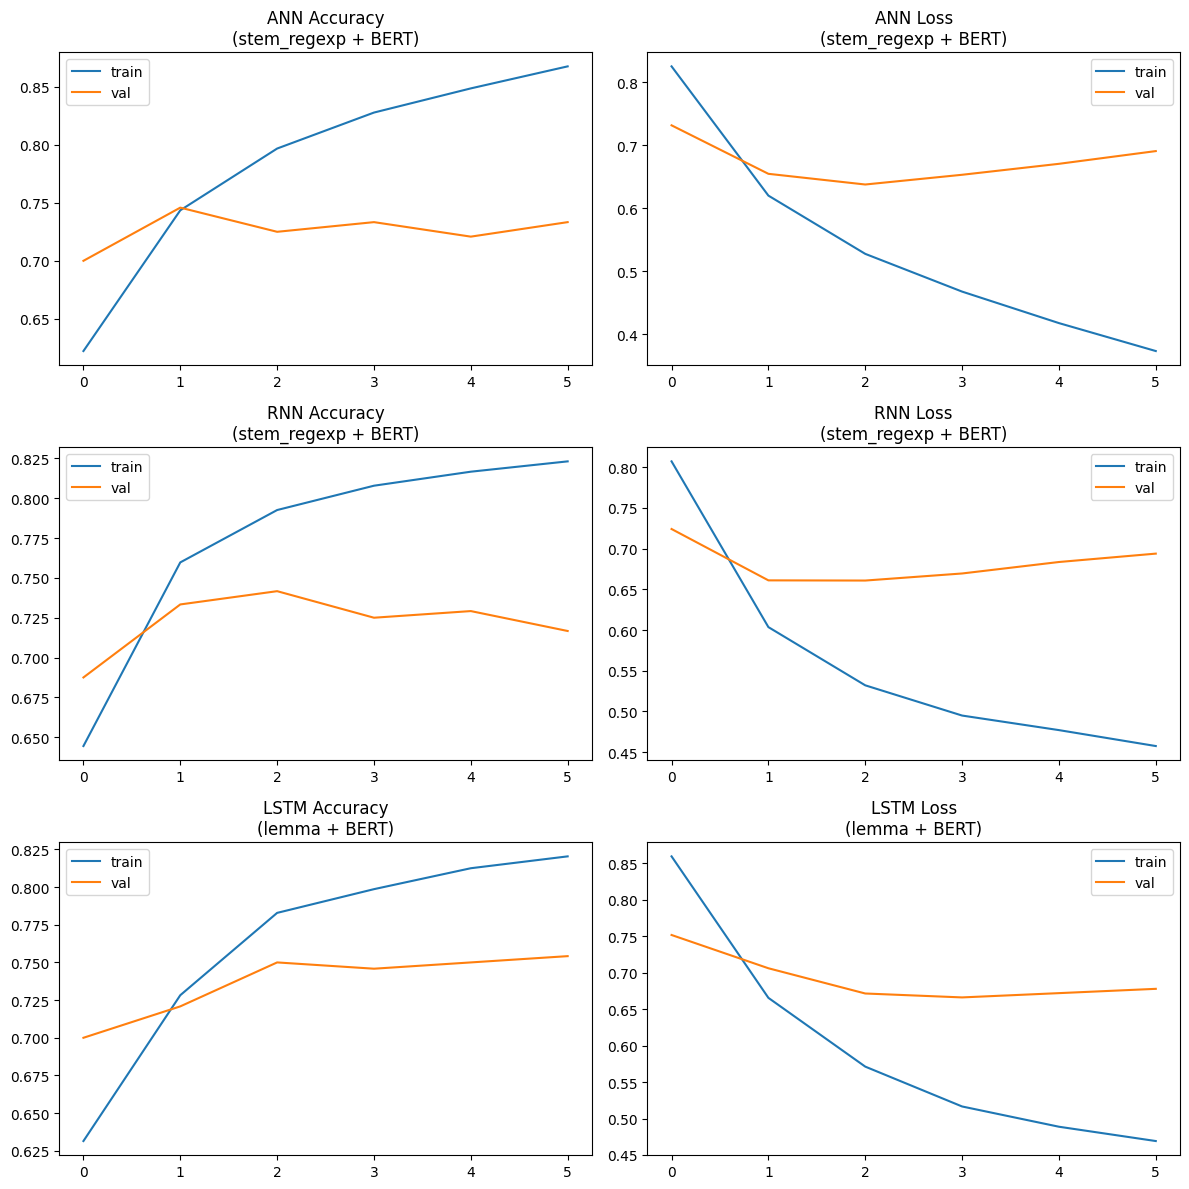

In [ ]:
fig, axes = plt.subplots(len(MODEL_BUILDERS), 2, figsize=(12, 4 * len(MODEL_BUILDERS)))
for row, model_name in enumerate(MODEL_BUILDERS.keys()):
    sub = results_df[results_df["model"] == model_name]
    best_row = sub.loc[sub["f1_macro"].idxmax()]
    key = (best_row["text_variant"], best_row["representation"], model_name)
    hist = histories[key].history
    axes[row, 0].plot(hist["accuracy"], label="train")
    axes[row, 0].plot(hist["val_accuracy"], label="val")
    axes[row, 0].set_title(f"{model_name} Accuracy\n({best_row['text_variant']} + {best_row['representation']})")
    axes[row, 0].legend()
    axes[row, 1].plot(hist["loss"], label="train")
    axes[row, 1].plot(hist["val_loss"], label="val")
    axes[row, 1].set_title(f"{model_name} Loss\n({best_row['text_variant']} + {best_row['representation']})")
    axes[row, 1].legend()
plt.tight_layout()
plt.show()

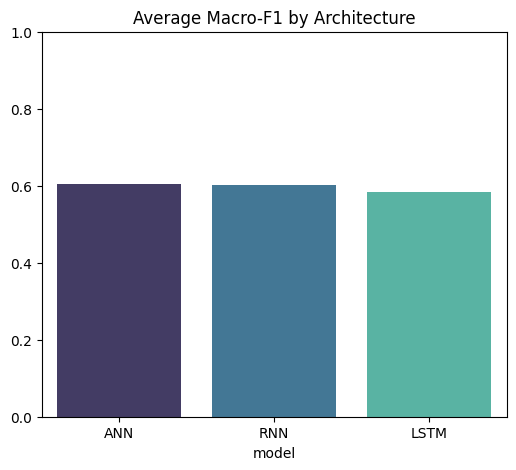

In [ ]:
plt.figure(figsize=(6, 5))
avg_by_model = results_df.groupby("model")["f1_macro"].mean().sort_values(ascending=False)
sns.barplot(x=avg_by_model.index, y=avg_by_model.values, palette="mako")
plt.title("Average Macro-F1 by Architecture")
plt.ylim(0, 1)
plt.show()

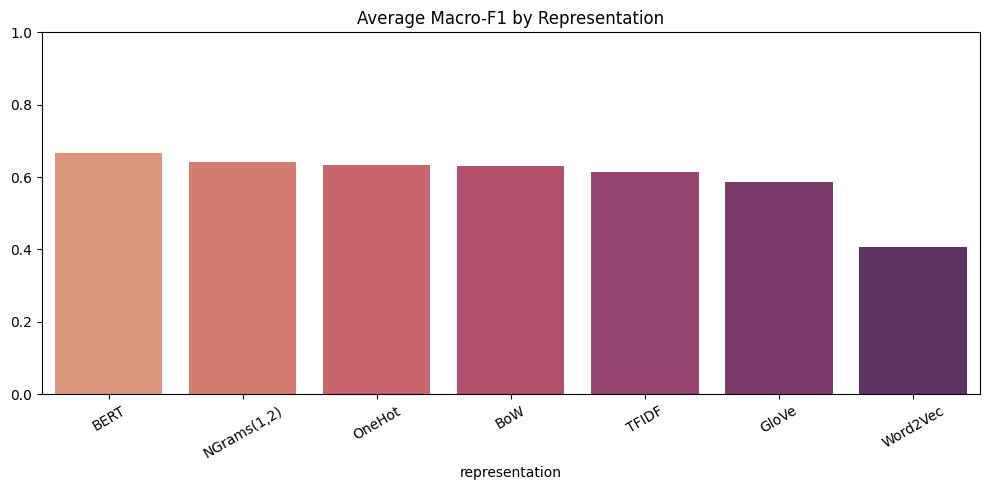

In [ ]:
plt.figure(figsize=(10, 5))
avg_by_rep = results_df.groupby("representation")["f1_macro"].mean().sort_values(ascending=False)
sns.barplot(x=avg_by_rep.index, y=avg_by_rep.values, palette="flare")
plt.title("Average Macro-F1 by Representation")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

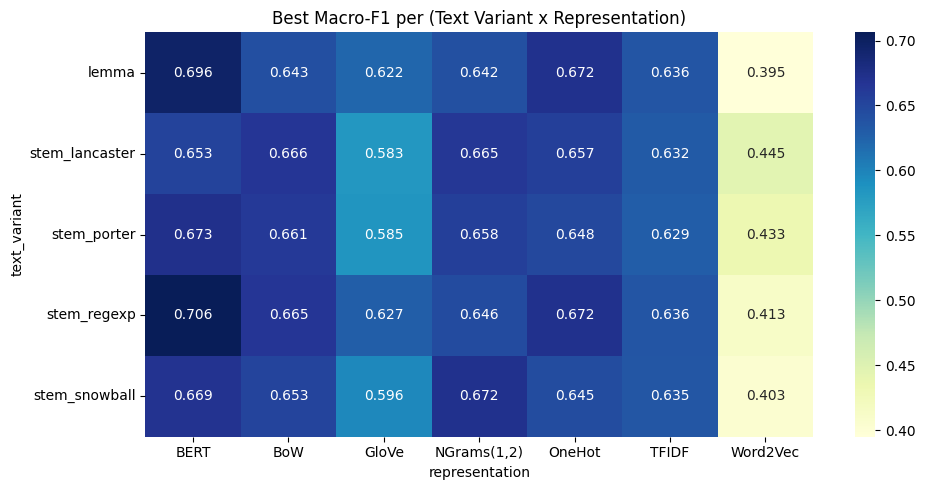

In [ ]:
pivot = results_df.pivot_table(index="text_variant", columns="representation", values="f1_macro", aggfunc="max")
plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Best Macro-F1 per (Text Variant x Representation)")
plt.tight_layout()
plt.show()

In [ ]:
best_overall = results_df.loc[results_df["f1_macro"].idxmax()]
print("BEST OVERALL EXPERIMENT")
print("Text Variant   :", best_overall["text_variant"])
print("Representation :", best_overall["representation"])
print("Model          :", best_overall["model"])
print(f"Accuracy        : {best_overall['accuracy']:.4f}")
print(f"Precision(macro): {best_overall['precision_macro']:.4f}")
print(f"Recall(macro)   : {best_overall['recall_macro']:.4f}")
print(f"F1(macro)       : {best_overall['f1_macro']:.4f}")
print(f"F1(weighted)    : {best_overall['f1_weighted']:.4f}")

BEST OVERALL EXPERIMENT
Text Variant   : stem_regexp
Representation : BERT
Model          : ANN
Accuracy        : 0.7783
Precision(macro): 0.7243
Recall(macro)   : 0.6932
F1(macro)       : 0.7063
F1(weighted)    : 0.7751


In [ ]:
import pickle

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

final_df.to_csv(f"{OUTPUT_DIR}/processed_dataset.csv", index=False)
results_df.to_csv(f"{OUTPUT_DIR}/all_results.csv", index=False)
ann_table.to_csv(f"{OUTPUT_DIR}/comparison_ANN.csv")
rnn_table.to_csv(f"{OUTPUT_DIR}/comparison_RNN.csv")
lstm_table.to_csv(f"{OUTPUT_DIR}/comparison_LSTM.csv")

best = best_overall
X_best = FEATURE_STORE[(best["text_variant"], best["representation"])]
X_train, X_test, y_train_int, y_test_int, y_train_cat, y_test_cat = split_data(X_best, y_int, y_cat)
tf.keras.backend.clear_session()
best_model = MODEL_BUILDERS[best["model"]](X_train.shape[1], NUM_CLASSES)
best_model.fit(X_train, y_train_cat, validation_split=0.1, epochs=EPOCHS, batch_size=32, callbacks=[EARLY_STOPPING()], verbose=0)
best_model.save(f"{OUTPUT_DIR}/best_model.keras")

best_corpus = final_df[best["text_variant"]].tolist()
if best["representation"] in ("OneHot", "BoW", "NGrams(1,2)", "TFIDF"):
    _, fitted_vectorizer = REPRESENTATIONS[best["representation"]](best_corpus)
    with open(f"{OUTPUT_DIR}/best_vectorizer.pkl", "wb") as f:
        pickle.dump(fitted_vectorizer, f)

w2v_tokenized = [s.split() for s in final_df[best["text_variant"]].tolist()]
w2v_model = Word2Vec(sentences=w2v_tokenized, **W2V_PARAMS)
w2v_model.save(f"{OUTPUT_DIR}/word2vec.model")

plt.figure(figsize=(7, 5))
sns.countplot(data=final_df, x="label_name", order=order, palette="viridis")
plt.title("Twitter US Airline Sentiment - Class Distribution")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/class_distribution.png", dpi=150)
plt.close()

print("Saved to:", os.path.abspath(OUTPUT_DIR))
print(os.listdir(OUTPUT_DIR))

Saved to: /content/outputs
['word2vec.model', 'processed_dataset.csv', 'all_results.csv', 'best_model.keras', 'class_distribution.png', 'comparison_ANN.csv', 'comparison_RNN.csv', 'comparison_LSTM.csv']
